In [24]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
import seaborn as sns

iris = load_iris(as_frame=True)
x = iris.data.iloc[:,2:].to_numpy()
y = (iris.target == 2) # Iris-virginica

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", LinearSVC(random_state=42, C=1))])

pipeline.fit(x, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', LinearSVC(C=1, random_state=42))])

In [11]:
iris

{'data':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 'target': 0     

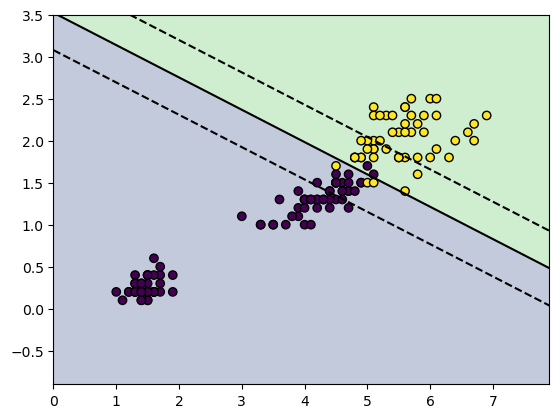

In [31]:
# 범위 설정
x0_min, x0_max =  x[:,0].min()-1, x[:,0].max()+1
x1_min, x1_max =  x[:,1].min()-1, x[:,1].max()+1

xx,yy = np.meshgrid(
    np.linspace(x0_min,x0_max,500),
    np.linspace(x1_min,x1_max,500)
)
grid = np.c_[xx.ravel(),yy.ravel()]

z = pipeline.predict(grid)
z = z.reshape(xx.shape)

plt.contourf(xx,yy,z, alpha=0.3)  # 결정영역
plt.scatter(x[:,0], x[:,1], c=y, edgecolors='k')

# 결정 경계
decision = pipeline.decision_function(grid)
decision = decision.reshape(xx.shape)
plt.contour(xx, yy, decision, levels = [-1,0,1], linestyles = ['--', '-', '--'], 
            colors='k')

plt.show()

In [33]:
# 파이프라인 만들어서 모델 학습, 예측값, f1-score

from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDClassifier, LogisticRegression

x, y = make_moons(n_samples=200, noise=0.1, random_state=42)

models = {'lr': LogisticRegression(random_stat=42)}
for model, label in models.items():

    pipeine =  make_pipeline(
        PolynomialFeatures(degree=3),
        StandardScaler(),
        LinearSVC(C=10, max_iter=10_000, random_state=42)
    )

pipeline.fit(x,y)
predict = pipeine.predict(x)
print(f'model --> {label}','-'*40)
print(classification_report(y,predict))

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'random_stat'

In [ ]:
# svm 적용

from sklearn.svm import SVC

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('svc',SVC(kernel='poly', degree=3, C=5,coef0=1))
    ('svc',SVC(kernel='rbf'))
])

pipeline.fit(x,y)
predict = pipeline.predict(x)
print(classification_report(y,predict))